### Signal Injection Test
Test discrimination power of spike search algorithm by injecting Gaussian signals into HARPS observations and looking for them.

In [215]:
%matplotlib widget

In [ ]:
eso_login = "goodmanj"
from astroquery.eso import Eso
eso = Eso()
eso.login(eso_login)

In [82]:
import sys
sys.path.append("..")
import optical_seti_functions
import seti_catalog_functions
import Gaussian_Injector
import csv
import random
import matplotlib.pyplot as plt
import numpy as np

In [204]:
import importlib
importlib.reload(Gaussian_Injector)

<module 'Gaussian_Injector' from 'c:\\Users\\goodm\\OneDrive\\Documents\\optical_seti\\injection\\Gaussian_Injector.py'>

In [208]:
# Pick 10 random targets from OSETI_targets.txt.
# Run this once to generate a list, then use the same list for all future runs.
with open("../OSETI_targets.txt") as f:
    dict_reader = csv.DictReader(f,delimiter='\t',fieldnames=["Target", "RA", "DEC", "SpType", "T_eff",	"B","V","G","Dist","Explore","products_ascii","products_csv"])
    OSETI_targets_dict = list(dict_reader)
n_rows = len(OSETI_targets_dict)
target_rows = [random.randint(0,n_rows-1) for i in range(10)]
targets = [OSETI_targets_dict[i]["Target"] for i in target_rows]
targets

['HD72968',
 'HIP56489',
 'HD50060',
 'HD92588',
 'GJ3187',
 'HD95521',
 'HD218566',
 'GJ1065',
 'HIP1119',
 'HD207700']

In [ ]:
# Use this particular list of targets every time this code is run
targets = ['HD72968',
 'HIP56489',
 'HD50060',
 'HD92588',
 'GJ3187',
 'HD95521',
 'HD218566',
 'GJ1065',
 'HIP1119',
 'HD207700']

In [ ]:
# Download one observation of each star, as needed
star_files = [seti_catalog_functions.download_one_obs(target,eso) for target in targets]

using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_02_09.883.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2021-05-19T01_02_07.372.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_03_01.833.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_03_31.423.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2016-01-11T01_03_47.070.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-24T09_41_30.860.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2016-06-21T01_04_10.871.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-29T13_27_04.900.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-01T10_21_34.313.fits
downloading ADP.2023-05-14T01:02:03.938
INFO: Detecting already downloaded datasets... [astroquery.eso.core]
INFO: Checking availability

313057
51631 4298.01


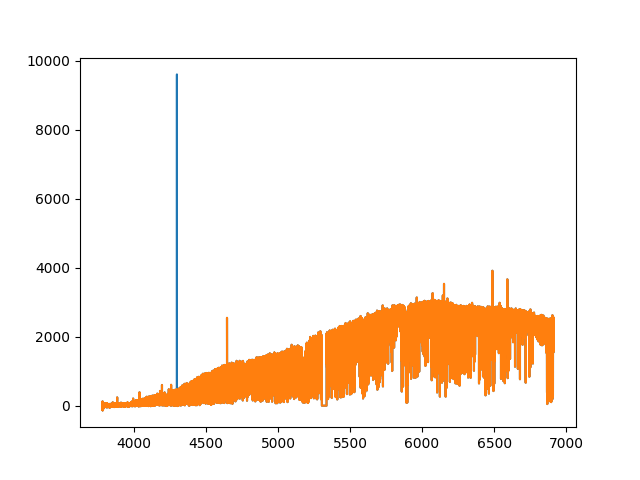

In [ ]:
# Plot one of the files with an example Gaussian injected.
[wave,arr1] = optical_seti_functions.read_harps_file(star_files[1][0])
array_length = len(arr1)
print(array_length)
center = random.randint(0,array_length)
print(center,wave[center])
modded_spectrum = Gaussian_Injector.add_gaussian_to_array(arr1,fwhm=10,center=float(center),array_length=array_length,area=20000)
plt.figure(1)
plt.clf()
plt.plot(wave,modded_spectrum,wave,arr1)
plt.show()

In [ ]:
# Main injection test.  Inject n_injected gaussians into each of the observations, and count the percentage of spikes successfully recovered.
# Do this for several areas[] under the Gaussian curve, and for several fwhms[].  Store the average recovery rate for each area and fwhm in recovery_rate_means[],
# and the standard deviation in recovery_rate_stdevss[].
n_injected = 10
areas = [10000,20000,100000]
fwhms = [4,10,20]
recovery_rate_means = np.zeros((len(areas),len(fwhms)))
recovery_rate_stdevs = np.zeros((len(areas),len(fwhms)))
for row in range(len(areas)):
    for col in range(len(fwhms)):
        area = areas[row]
        fwhm = fwhms[col]
        recovery_rates = [];
        for s in star_files:
            print(s[0])
            [wave,arr1] = optical_seti_functions.read_harps_file(s[0])
            if len(arr1)==0:
                continue
            # Perform SETI spike analysis on original spectrum
            hits_start, hits_end,count  = optical_seti_functions.seti_spike_analyzer(arr1, min_count = 4, max_count = 60, threshold_multiplier = 3.5, window_size = 101)
            count = len(hits_start)
            print(s[1],count)
            # Inject 10 random Gaussian signals
            injected_recovery_count = 0
            for n in range(n_injected):
                center = random.randint(0,array_length)
                modded_spectrum = Gaussian_Injector.add_gaussian_to_array(arr1, fwhm = float(10), amplitude=None, center=float(center), array_length=array_length, axis=-1, area=float(area))
                hits_start, hits_end, newcount = optical_seti_functions.seti_spike_analyzer(modded_spectrum, min_count = 4, max_count = 60, threshold_multiplier = 3.5, window_size = 101)
                injected_recovery_count = injected_recovery_count +len(hits_start) - count

            recovery_rates.append(float(injected_recovery_count)/n_injected)
        recovery_rate_means[row,col] = np.mean(recovery_rates)
        recovery_rate_stdevs[row,col] = np.std(recovery_rates)
print(recovery_rate_means)
print(recovery_rate_stdevs)


C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_02_09.883.fits
[] []
HR-3398 0
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2021-05-19T01_02_07.372.fits
[] []
BD-123458 0
[27958] [27962]
[] []
[] []
[] []
[] []
[294148] [294153]
[] []
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_03_01.833.fits
[] []
HD50060 0
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_03_31.423.fits
[] []
HD92588 0
[] []
[] []
[] []
[] []
[] []
[] []
[152477] [152482]
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2016-01-11T01_03_47.070.fits
[] []
HD17970 0
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-24T09_41_30.860.fits
[] []
HD95521 0
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
[] []
C:\Users\goodm\.astropy\cache\astroquery

Example results:

Mean:

|          | FWHM=4 | 10  | 20 |
|----------|--------|-----|----|
|Area=10000| .19    | .14 | .16|
|   20000  | .24    | .25 | .2 |
|  100000  | .47    | .50 | .47|

Stdev:

|          | FWHM=4 | 10  | 20 |
|----------|--------|-----|----|
|Area=10000| .31    | .26 | .26|
|   20000  | .28    | .32 | .31|
|  100000  | .27    | .36 | .30|

Recovery is mediocre and highly spotty.  Some files give >70% recovery rate while others give zero.  Density and depth of spectral lines in the star spectrum seems to be a major factor.

I don't see a clear sign that FWHM matters much: even with FWHM=20, recovery is poor.

In [218]:
recovery_rate_stdevs

array([[0.30805844, 0.26153394, 0.26532998],
       [0.28      , 0.31701735, 0.30983867],
       [0.26851443, 0.36055513, 0.30016662]])

In [172]:
targets

['WASP-42',
 'HD121416',
 'HD105850',
 'HD11195',
 'HD212231',
 'HIP47',
 'HD129926',
 'HD5891',
 'GJ660.1',
 'HD223282']